In [1]:
from timeit import default_timer as timer
from typing import Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.optim import SGD
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm

In [ ]:
def get_device() -> torch.device:
    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
    x = torch.ones(1, device=device)

    return device

In [3]:
device = get_device()
print(f"device: {device}")

# Umschalten zwischen Colab oder lokaler Installation
USING_COLAB = False

mps
device: mps


Download and load the training data


In [4]:
def get_data(batch_size: int = 32) -> Tuple[DataLoader, DataLoader]:
    transform = transforms.Compose(
        [
            # Converts to float and normalizes from [0, 255] to [0, 1]
            transforms.ToTensor(),
            # Flattens the 2D image 28x28 to 1D vector 784
            transforms.Lambda(lambda x: x.view(-1)),
        ]
    )

    train_set = datasets.MNIST("data/", download=True, train=True, transform=transform)
    test_set = datasets.MNIST("data/", download=True, train=False, transform=transform)

    train_dl = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    test_dl = DataLoader(test_set, batch_size=len(test_set), shuffle=False)

    return train_dl, test_dl

Modell (KNN) definieren mit beliebig vielen Schichten, die jeweils variable Anzahl Neuronen beinhalten. Wir beginnen hier immer mit 28x28 Eingabe-Neuronen und müssen am Ende immer auf 10 Ausgabe-Neuronen kommen


In [5]:
def get_model() -> tuple[nn.Module, nn.Module, SGD]:
    model = nn.Sequential(
        nn.Linear(28 * 28, 50),
        nn.Tanh(),
        nn.Linear(50, 40),
        nn.Tanh(),
        nn.Linear(40, 30),
        nn.Tanh(),
        nn.Linear(30, 20),
        nn.Tanh(),
        nn.Linear(20, 10),
    ).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = SGD(model.parameters(), lr=1e-2)

    return model, loss_fn, optimizer

In [6]:
def init_weights(m: nn.Module):
    if type(m) == nn.Linear:
        # m.weight.data.fill_(1)
        # m.weight.data.uniform_(-0.1, 0.1)
        m.weight.data.normal_(0.0, 0.1)
        if m.bias is not None:
            m.bias.data.fill_(0)

In [ ]:
def train_batch(
    x: torch.Tensor, y: torch.Tensor, model: nn.Module, opt: SGD, loss_fn: nn.Module
) -> float:
    model.train()

    prediction = model(x)
    #print(f"prediction.shape {prediction.shape}")

    batch_loss = loss_fn(prediction, y)
    #print(f"batch_loss {batch_loss}")

    batch_loss.backward()
    opt.step()
    opt.zero_grad()

    return batch_loss.item()

In [8]:
def accuracy(x: torch.Tensor, y: torch.Tensor, model: nn.Module):
    model.eval()
    with torch.no_grad():
        prediction = model(x)

    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y

    return is_correct.cpu().numpy().tolist()

In [9]:
def loss(x: torch.Tensor, y: torch.Tensor, model: nn.Module, loss_fn: nn.Module):
    model.eval()
    with torch.no_grad():
        prediction = model(x)
        loss = loss_fn(prediction, y)

    return loss.item()

In [10]:
train_dl, test_dl = get_data()
model, loss_fn, optimizer = get_model()

100%|██████████| 9.91M/9.91M [00:14<00:00, 680kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 295kB/s]
100%|██████████| 1.65M/1.65M [00:06<00:00, 260kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.63MB/s]


In [11]:
# ----------------------------------------------
# Training >>>
#
print("Starting training...")

# Hier werden die initialen Gewichte des Netzes zufällig gesetzt
# model.apply(init_weights)

epochs = 50

arrPlotX = []
train_losses, train_accuracies = [], []
test_losses, test_accuracies = [], []
for epoch in tqdm(range(epochs)):
    timeBeginEpoch = timer()
    train_epoch_losses, train_epoch_accuracies = [], []

    for ix, batch in enumerate(iter(train_dl)):
        x, y = batch
        x, y = x.to(device), y.to(device)
        # print(f"x.shape: {x.shape}  y.shape: {y.shape}\n")

        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)

    train_epoch_loss = np.array(train_epoch_losses).mean()
    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for ix, batch in enumerate(iter(test_dl)):
        x, y = batch
        x, y = x.to(device), y.to(device)

        val_is_correct = accuracy(x, y, model)
        validation_loss = loss(x, y, model, loss_fn)

    val_epoch_accuracy = np.mean(val_is_correct)
    arrPlotX.append(epoch)
    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    test_losses.append(validation_loss)
    test_accuracies.append(val_epoch_accuracy)
    timeEndEpoch = timer()
    print(
        f"epoch: {epoch}, train_acc: {100 * train_epoch_accuracy:.2f}%, test_acc: {100 * val_epoch_accuracy:.2f}%, took {timeEndEpoch-timeBeginEpoch:.1f}s"
    )

Starting training...


  0%|          | 0/50 [00:00<?, ?it/s]

prediction.shape torch.Size([32, 10])
batch_loss 2.314413547515869
prediction.shape torch.Size([32, 10])
batch_loss 2.2909092903137207
prediction.shape torch.Size([32, 10])
batch_loss 2.2984111309051514
prediction.shape torch.Size([32, 10])
batch_loss 2.311674118041992
prediction.shape torch.Size([32, 10])
batch_loss 2.3292012214660645
prediction.shape torch.Size([32, 10])
batch_loss 2.3133723735809326
prediction.shape torch.Size([32, 10])
batch_loss 2.337263584136963
prediction.shape torch.Size([32, 10])
batch_loss 2.329625129699707
prediction.shape torch.Size([32, 10])
batch_loss 2.3053174018859863
prediction.shape torch.Size([32, 10])
batch_loss 2.3200018405914307
prediction.shape torch.Size([32, 10])
batch_loss 2.3326773643493652
prediction.shape torch.Size([32, 10])
batch_loss 2.322314500808716
prediction.shape torch.Size([32, 10])
batch_loss 2.3133225440979004
prediction.shape torch.Size([32, 10])
batch_loss 2.33603572845459
prediction.shape torch.Size([32, 10])
batch_loss 2.2969

  2%|▏         | 1/50 [00:11<09:32, 11.69s/it]

epoch: 0, train_acc: 41.41%, test_acc: 71.40%, took 11.7s
prediction.shape torch.Size([32, 10])
batch_loss 1.0403919219970703
prediction.shape torch.Size([32, 10])
batch_loss 1.1403148174285889
prediction.shape torch.Size([32, 10])
batch_loss 0.9564526081085205
prediction.shape torch.Size([32, 10])
batch_loss 1.1669905185699463
prediction.shape torch.Size([32, 10])
batch_loss 0.9006243348121643
prediction.shape torch.Size([32, 10])
batch_loss 1.1308443546295166
prediction.shape torch.Size([32, 10])
batch_loss 0.9038270711898804
prediction.shape torch.Size([32, 10])
batch_loss 1.2448903322219849
prediction.shape torch.Size([32, 10])
batch_loss 1.2898041009902954
prediction.shape torch.Size([32, 10])
batch_loss 0.9516988396644592
prediction.shape torch.Size([32, 10])
batch_loss 1.164578914642334
prediction.shape torch.Size([32, 10])
batch_loss 1.1772243976593018
prediction.shape torch.Size([32, 10])
batch_loss 1.3418495655059814
prediction.shape torch.Size([32, 10])
batch_loss 1.12409591

...

epoch: 47, train_acc: 99.89%, test_acc: 97.15%, took 9.3s
prediction.shape torch.Size([32, 10])
batch_loss 0.008654198609292507
prediction.shape torch.Size([32, 10])
batch_loss 0.0052420757710933685
prediction.shape torch.Size([32, 10])
batch_loss 0.037141766399145126
prediction.shape torch.Size([32, 10])
batch_loss 0.08808412402868271
prediction.shape torch.Size([32, 10])
batch_loss 0.005804640240967274
prediction.shape torch.Size([32, 10])
batch_loss 0.0008315673330798745
prediction.shape torch.Size([32, 10])
batch_loss 0.03652949631214142
prediction.shape torch.Size([32, 10])
batch_loss 0.001121033332310617
prediction.shape torch.Size([32, 10])
batch_loss 0.005303072277456522
prediction.shape torch.Size([32, 10])
batch_loss 0.0008199803996831179
prediction.shape torch.Size([32, 10])
batch_loss 0.0021590152755379677
prediction.shape torch.Size([32, 10])
batch_loss 0.03414159268140793
prediction.shape torch.Size([32, 10])
batch_loss 0.02227473445236683
prediction.shape torch.Size([32,

 98%|█████████▊| 49/50 [07:37<00:09,  9.29s/it]

epoch: 48, train_acc: 99.89%, test_acc: 97.20%, took 9.3s
prediction.shape torch.Size([32, 10])
batch_loss 0.14888979494571686
prediction.shape torch.Size([32, 10])
batch_loss 0.024419691413640976
prediction.shape torch.Size([32, 10])
batch_loss 0.005811876617372036
prediction.shape torch.Size([32, 10])
batch_loss 0.012961767613887787
prediction.shape torch.Size([32, 10])
batch_loss 0.0015717875212430954
prediction.shape torch.Size([32, 10])
batch_loss 0.0012944936752319336
prediction.shape torch.Size([32, 10])
batch_loss 0.008878582157194614
prediction.shape torch.Size([32, 10])
batch_loss 0.02125535160303116
prediction.shape torch.Size([32, 10])
batch_loss 0.006549469195306301
prediction.shape torch.Size([32, 10])
batch_loss 0.01693212427198887
prediction.shape torch.Size([32, 10])
batch_loss 0.007157131098210812
prediction.shape torch.Size([32, 10])
batch_loss 0.006577625405043364
prediction.shape torch.Size([32, 10])
batch_loss 0.0017910193419083953
prediction.shape torch.Size([32,

100%|██████████| 50/50 [07:46<00:00,  9.34s/it]

epoch: 49, train_acc: 99.89%, test_acc: 97.12%, took 9.5s


In [ ]:
if USING_COLAB:
    torch.save(
        model.state_dict(),
        "/content/drive/My Drive/ColabNotebooks/results/bv2_a02_nnMnist_exp01.pt",
    )
else:
    torch.save(model.state_dict(), "bv2_a02_nnMnist_exp01.pt")

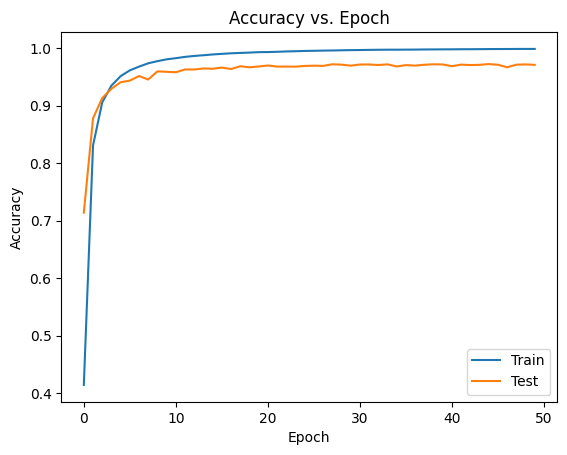

In [ ]:
plt.plot(arrPlotX, train_accuracies)
plt.plot(arrPlotX, test_accuracies)
plt.title("Accuracy vs. Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Test"])

if USING_COLAB:
    plt.savefig("/content/drive/My Drive/ColabNotebooks/results/bv2_a02_accuracies_exp0.png")
else:
    plt.savefig("bv2_a02_accuracies_exp0.png")

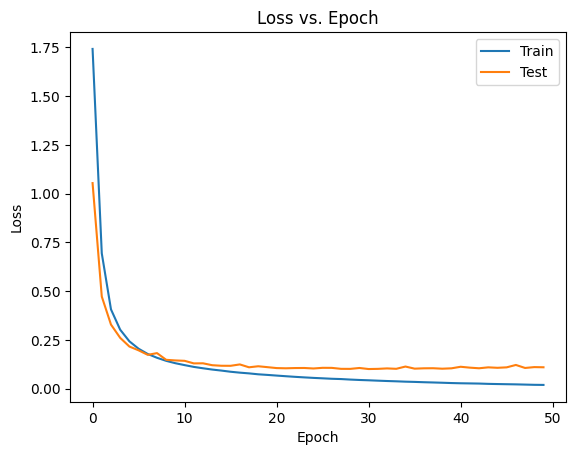

In [ ]:
plt.plot(arrPlotX, train_losses)
plt.plot(arrPlotX, test_losses)
plt.title("Loss vs. Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Test"])

if USING_COLAB:
    plt.savefig("/content/drive/My Drive/ColabNotebooks/results/bv2_a02_losses_exp0.png")
else:
    plt.savefig("bv2_a02_losses_exp0.png")

# Hyperparameter tuning
## Subtask:
Experiment with different hyperparameters such as learning rate, batch size, and number of epochs to find the optimal combination for better performance.

## Reasoning: 
Modify the existing code to incorporate hyperparameter tuning by defining variables for learning rate, batch size, and number of epochs and then running the training process with different combinations of these hyperparameters. Track the training and test loss and accuracy for each combination.

In [ ]:
def train_model(learning_rate, batch_size, epochs):
    print(f"Training with LR: {learning_rate}, Batch Size: {batch_size}, Epochs: {epochs}")
    train_dl, test_dl = get_data(batch_size=batch_size)
    model, loss_fn, optimizer = get_model()
    optimizer = SGD(model.parameters(), lr=learning_rate) # Update optimizer with new learning rate

    arrPlotX = []
    train_losses, train_accuracies = [], []
    test_losses, test_accuracies = [], []

    for epoch in tqdm(range(epochs)):
        train_epoch_losses, train_epoch_accuracies = [], []

        for ix, batch in enumerate(iter(train_dl)):
            x, y = batch
            x, y = x.to(device), y.to(device)
            batch_loss = train_batch(x, y, model, optimizer, loss_fn)
            train_epoch_losses.append(batch_loss)
            is_correct = accuracy(x, y, model)
            train_epoch_accuracies.extend(is_correct)

        train_epoch_loss = np.array(train_epoch_losses).mean()
        train_epoch_accuracy = np.mean(train_epoch_accuracies)

        for ix, batch in enumerate(iter(test_dl)):
            x, y = batch
            x, y = x.to(device), y.to(device)
            val_is_correct = accuracy(x, y, model)
            validation_loss = loss(x, y, model, loss_fn)

        val_epoch_accuracy = np.mean(val_is_correct)
        arrPlotX.append(epoch)
        train_losses.append(train_epoch_loss)
        train_accuracies.append(train_epoch_accuracy)
        test_losses.append(validation_loss)
        test_accuracies.append(val_epoch_accuracy)

    print(f"Final Test Accuracy: {100 * test_accuracies[-1]:.2f}%")
    return train_losses, train_accuracies, test_losses, test_accuracies

# Define hyperparameter ranges
learning_rates = [1e-2, 1e-3, 1e-4]
batch_sizes = [32, 64]
epochs_list = [20, 50]

results = {}

for lr in learning_rates:
    for bs in batch_sizes:
        for ep in epochs_list:
            train_losses, train_accuracies, test_losses, test_accuracies = train_model(lr, bs, ep)
            results[(lr, bs, ep)] = {
                'train_losses': train_losses,
                'train_accuracies': train_accuracies,
                'test_losses': test_losses,
                'test_accuracies': test_accuracies
            }

### Output for 748 / 16 / 16 / 10
Training with LR: 0.01, Batch Size: 32, Epochs: 20
100%|██████████| 20/20 [03:35<00:00, 10.78s/it]
Final Test Accuracy: 95.13%
Training with LR: 0.01, Batch Size: 32, Epochs: 50
100%|██████████| 50/50 [08:59<00:00, 10.79s/it]
Final Test Accuracy: 95.51%
Training with LR: 0.01, Batch Size: 64, Epochs: 20
100%|██████████| 20/20 [02:57<00:00,  8.90s/it]
Final Test Accuracy: 94.57%
Training with LR: 0.01, Batch Size: 64, Epochs: 50
100%|██████████| 50/50 [07:23<00:00,  8.88s/it]
Final Test Accuracy: 94.88%
Training with LR: 0.001, Batch Size: 32, Epochs: 20
100%|██████████| 20/20 [03:35<00:00, 10.77s/it]
Final Test Accuracy: 88.53%
Training with LR: 0.001, Batch Size: 32, Epochs: 50
100%|██████████| 50/50 [08:58<00:00, 10.77s/it]
Final Test Accuracy: 92.31%
Training with LR: 0.001, Batch Size: 64, Epochs: 20
100%|██████████| 20/20 [02:58<00:00,  8.92s/it]
Final Test Accuracy: 70.48%
Training with LR: 0.001, Batch Size: 64, Epochs: 50
100%|██████████| 50/50 [07:23<00:00,  8.88s/it]
Final Test Accuracy: 89.50%
Training with LR: 0.0001, Batch Size: 32, Epochs: 20
100%|██████████| 20/20 [03:34<00:00, 10.73s/it]
Final Test Accuracy: 34.19%
Training with LR: 0.0001, Batch Size: 32, Epochs: 50
100%|██████████| 50/50 [08:56<00:00, 10.74s/it]
Final Test Accuracy: 57.23%
Training with LR: 0.0001, Batch Size: 64, Epochs: 20
100%|██████████| 20/20 [02:56<00:00,  8.82s/it]
Final Test Accuracy: 21.08%
Training with LR: 0.0001, Batch Size: 64, Epochs: 50
100%|██████████| 50/50 [07:21<00:00,  8.82s/it]Final Test Accuracy: 45.04%



## Output for 748 / 128 / 64 / 10
Training with LR: 0.01, Batch Size: 32, Epochs: 20
100%|██████████| 20/20 [03:44<00:00, 11.21s/it]
Final Test Accuracy: 96.70%
Training with LR: 0.01, Batch Size: 32, Epochs: 50
100%|██████████| 50/50 [09:19<00:00, 11.19s/it]
Final Test Accuracy: 97.18%
Training with LR: 0.01, Batch Size: 64, Epochs: 20
100%|██████████| 20/20 [03:02<00:00,  9.11s/it]
Final Test Accuracy: 95.57%
Training with LR: 0.01, Batch Size: 64, Epochs: 50
100%|██████████| 50/50 [07:43<00:00,  9.27s/it]
Final Test Accuracy: 96.96%
Training with LR: 0.001, Batch Size: 32, Epochs: 20
100%|██████████| 20/20 [03:44<00:00, 11.22s/it]
Final Test Accuracy: 87.89%
Training with LR: 0.001, Batch Size: 32, Epochs: 50
100%|██████████| 50/50 [09:19<00:00, 11.19s/it]
Final Test Accuracy: 94.05%
Training with LR: 0.001, Batch Size: 64, Epochs: 20
100%|██████████| 20/20 [03:02<00:00,  9.11s/it]
Final Test Accuracy: 74.32%
Training with LR: 0.001, Batch Size: 64, Epochs: 50
100%|██████████| 50/50 [07:31<00:00,  9.02s/it]
Final Test Accuracy: 89.36%
Training with LR: 0.0001, Batch Size: 32, Epochs: 20
100%|██████████| 20/20 [03:41<00:00, 11.09s/it]
Final Test Accuracy: 28.57%
Training with LR: 0.0001, Batch Size: 32, Epochs: 50
100%|██████████| 50/50 [09:15<00:00, 11.10s/it]
Final Test Accuracy: 48.44%
Training with LR: 0.0001, Batch Size: 64, Epochs: 20
100%|██████████| 20/20 [03:00<00:00,  9.01s/it]
Final Test Accuracy: 29.17%
Training with LR: 0.0001, Batch Size: 64, Epochs: 50
100%|██████████| 50/50 [07:31<00:00,  9.02s/it]Final Test Accuracy: 27.34%

